<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/05_Lab_regresion_y_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio 4 — Regresión lineal y clasificación

## Cómo trabajar

* Las celdas marcadas con ✏️ **Ejercicio** tienen huecos `...` que usted debe completar.
* Después de cada ejercicio hay una celda ✅ **Checkpoint**: si corre sin errores, su implementación es correcta.
* Las demás celdas son de lectura y ejecución: córralas en orden, de arriba hacia abajo.

**Duración estimada:** 3 horas. **Entregable:** este mismo notebook ejecutado + las respuestas de la sección final.

## 0. Preparación

Ejecute esta celda una sola vez.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

rng = np.random.default_rng(42)
print("Listo. numpy", np.__version__)

Listo. numpy 2.4.6


### La receta de 5 pasos

Todo lo que sigue —regresión lineal, multivariada y clasificación— es la **misma receta** con piezas distintas:

| Paso | Qué se elige | Regresión lineal | Regresión logística |
|---|---|---|---|
| 1 | Hipótesis $h_\Theta(X)$ | $\Theta^T X$ | $\sigma(\Theta^T X)$ |
| 2 | Función de coste $J(\Theta)$ | error cuadrático | entropía cruzada |
| 3 | Gradiente $\nabla_\Theta J$ | $\frac{1}{m}X^T(h-y)$ | $\frac{1}{m}X^T(h-y)$ |
| 4 | Optimizador | gradiente descendente / ecuación normal | gradiente descendente |
| 5 | Evaluación | $J$, $R^2$ | exactitud, curvas de aprendizaje |

Fíjese desde ya en la fila 3: **el gradiente tiene exactamente la misma forma en los dos modelos**. Volveremos a esto en la Parte 6.

> *Non-Free-Lunch Theorem*: no existe un algoritmo universalmente mejor. Siempre conviene inyectar conocimiento del problema.

---
# Parte 1 — Una característica: hipótesis y función de coste

Tenemos $m$ pares de entrenamiento $(x^{(1)},y^{(1)}),\dots,(x^{(m)},y^{(m)})$ y proponemos la hipótesis lineal

$$h_\theta(x) = \theta_0 + \theta_1 x$$

La calidad del ajuste se mide con la **función de coste** (métrica euclidiana):

$$J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)^2$$

Entrenar = **encontrar el mínimo de $J$**.

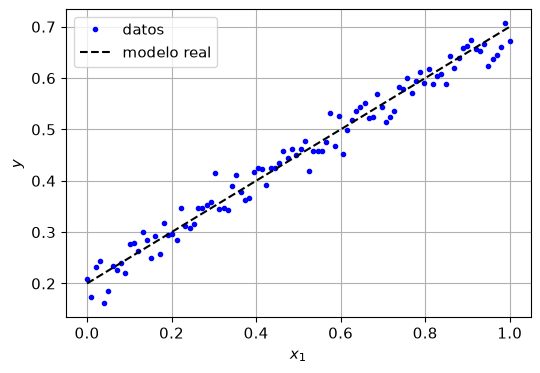

[0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909 0.1010101  0.11111111
 0.12121212 0.13131313 0.14141414 0.15151515 0.16161616 0.17171717
 0.18181818 0.19191919 0.2020202  0.21212121 0.22222222 0.23232323
 0.24242424 0.25252525 0.26262626 0.27272727 0.28282828 0.29292929
 0.3030303  0.31313131 0.32323232 0.33333333 0.34343434 0.35353535
 0.36363636 0.37373737 0.38383838 0.39393939 0.4040404  0.41414141
 0.42424242 0.43434343 0.44444444 0.45454545 0.46464646 0.47474747
 0.48484848 0.49494949 0.50505051 0.51515152 0.52525253 0.53535354
 0.54545455 0.55555556 0.56565657 0.57575758 0.58585859 0.5959596
 0.60606061 0.61616162 0.62626263 0.63636364 0.64646465 0.65656566
 0.66666667 0.67676768 0.68686869 0.6969697  0.70707071 0.71717172
 0.72727273 0.73737374 0.74747475 0.75757576 0.76767677 0.77777778
 0.78787879 0.7979798  0.80808081 0.81818182 0.82828283 0.83838384
 0.84848485 0.85858586 0.86868687 0.87878788 0.88888889 0.89898

In [2]:
# Datos sintéticos: conocemos la respuesta (theta_0 = 0.2, theta_1 = 0.5)
m = 100
X = np.linspace(0, 1, m)
theta_real = (0.2, 0.5)
y = theta_real[0] + theta_real[1] * X + rng.normal(0, 0.03, m)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.", label="datos")
plt.plot(X, theta_real[0] + theta_real[1] * X, "k--", label="modelo real")
plt.xlabel("$x_1$"); plt.ylabel("$y$"); plt.legend(); plt.show()
print(X)

In [3]:
def H(X, t0, t1):
    """Hipótesis lineal h(x) = t0 + t1*x."""
    return t0 + t1 * X


def J(t0, t1, X, y):
    """Función de coste (error cuadrático medio / 2)."""
    return ((H(X, t0, t1) - y) ** 2).mean() / 2


print("J en el óptimo teórico:", round(J(*theta_real, X, y), 6)) # Equivalente a: J(theta_real[0], theta_real[1], X, y)
print("J en un punto malo   :", round(J(0.0, 3.0, X, y), 6))     # Intento inventado lejos del real


J en el óptimo teórico: 0.00027
J en un punto malo   : 0.821456


Observar que con el J óptimo teórico el coste es casi cero.

### ✏️ Ejercicio 1.1 — Barrido de $\theta_1$

Fije $\theta_0 = 0.2$ y evalúe $J$ sobre una malla de valores de $\theta_1$. Complete la línea marcada.

In [4]:
t1_grid = np.linspace(-1, 2, 300)

# TODO: evalúe J(0.2, t1, X, y) para cada t1 de t1_grid
J_grid = []

for j in t1_grid:
    J_grid.append(J(0.2, j, X, y))

t1_opt = t1_grid[np.argmin(J_grid)]                 # valor de t1 optimizado
print("theta_1 que minimiza J:", round(t1_opt, 4))

J_grid = np.array(J_grid)



theta_1 que minimiza J: 0.495


In [5]:
# ✅ Checkpoint 1.1
assert np.shape(J_grid) == (300,), "J_grid debe tener un valor por cada theta_1"
assert abs(t1_opt - theta_real[1]) < 0.05, "el mínimo no coincide con la pendiente real" # valor encontrado razonablemente cerca del real
print("Correcto ✔")

Correcto ✔


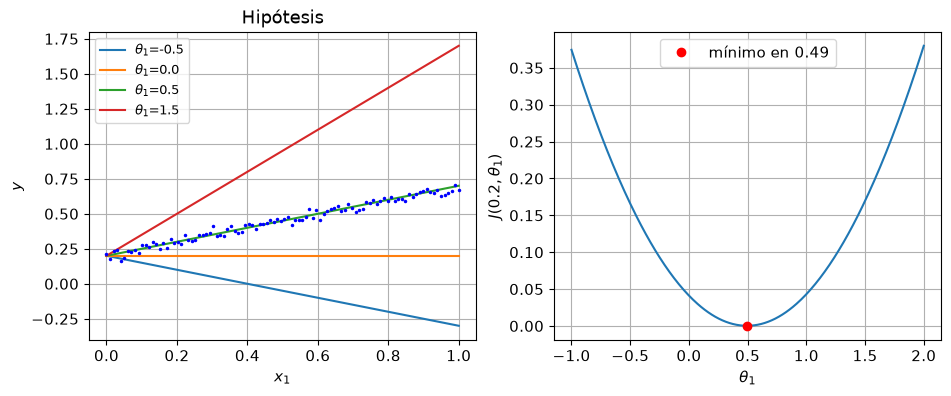

In [6]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
for t1 in [-0.5, 0.0, 0.5, 1.5]:
    plt.plot(X, H(X, 0.2, t1), label=f"$\\theta_1$={t1}")
plt.plot(X, y, "b.", ms=3)
plt.xlabel("$x_1$"); plt.ylabel("$y$"); plt.legend(fontsize=9); plt.title("Hipótesis")

plt.subplot(122)
plt.plot(t1_grid, J_grid)
plt.plot(t1_opt, J_grid.min(), "ro", label=f"mínimo en {t1_opt:.2f}")
plt.xlabel("$\\theta_1$"); plt.ylabel("$J(0.2,\\theta_1)$"); plt.legend(); plt.show()

### La superficie de coste

Con dos parámetros, $J$ es una **superficie** en $\mathbb{R}^3$ y el entrenamiento consiste en bajar hasta su fondo. Para el error cuadrático esa superficie es un paraboloide: **convexa**, con un único mínimo global.

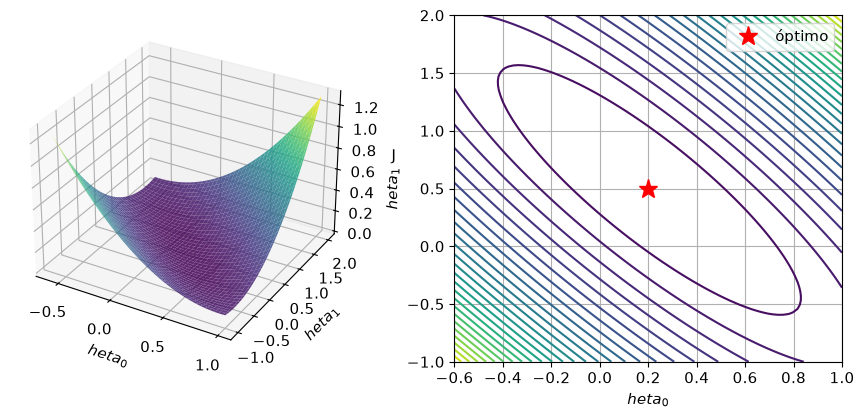

[[1.29322126 1.2620645  1.23131792 ... 0.09436818 0.0947961  0.0956342 ]
 [1.25925898 1.22848677 1.19812475 ... 0.09001654 0.09082901 0.09205167]
 [1.22577982 1.19539216 1.16541469 ... 0.08614802 0.08734504 0.08895225]
 ...
 [0.0917344  0.09018827 0.08905234 ... 1.17290055 1.2029391  1.23338785]
 [0.09497235 0.09381078 0.0930594  ... 1.20574914 1.23617225 1.26700555]
 [0.09869342 0.0979164  0.09754958 ... 1.23908085 1.26988851 1.30110637]]


In [7]:
t0g, t1g = np.meshgrid(np.linspace(-0.6, 1.0, 80), np.linspace(-1.0, 2.0, 80))
Jg = np.array([[J(a, b, X, y) for a, b in zip(fa, fb)] for fa, fb in zip(t0g, t1g)])

fig = plt.figure(figsize=(11, 4.5))
ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(t0g, t1g, Jg, cmap="viridis", alpha=0.85)
ax.set_xlabel(r"$	heta_0$"); ax.set_ylabel(r"$	heta_1$"); ax.set_zlabel("J")

ax2 = fig.add_subplot(122)
cs = ax2.contour(t0g, t1g, Jg, 30, cmap="viridis")
ax2.plot(*theta_real, "r*", ms=14, label="óptimo")
ax2.set_xlabel(r"$	heta_0$"); ax2.set_ylabel(r"$	heta_1$"); ax2.legend()
plt.show()

print(Jg)

---
# Parte 2 — Gradiente descendente

Para bajar por la superficie usamos la regla de actualización

$$\theta_j := \theta_j - \alpha\,\frac{\partial J}{\partial \theta_j}$$

donde $\alpha$ es la **tasa de aprendizaje**. Primero, la intuición en 1D con $f(w)=(w-1)^2$, cuyo mínimo está en $w=1$.

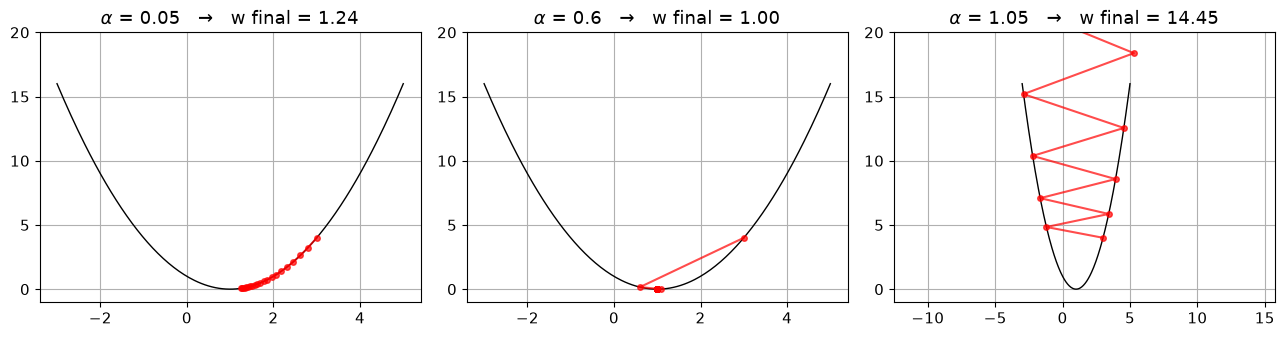

In [8]:
f  = lambda w: (w - 1) ** 2
fp = lambda w: 2 * (w - 1)


def descenso_1d(w0, alpha, n_iter=20):
    w, hist = w0, [w0]
    for _ in range(n_iter):
        w = w - alpha * fp(w)
        hist.append(w)
    return np.array(hist)


w = np.linspace(-3, 5, 200)
plt.figure(figsize=(13, 3.5))
for k, alpha in enumerate([0.05, 0.6, 1.05]):
    hist = descenso_1d(3.0, alpha)
    plt.subplot(1, 3, k + 1)
    plt.plot(w, f(w), "k-", lw=1)
    plt.plot(hist, f(hist), "ro-", ms=4, alpha=0.7)
    plt.title(f"$\\alpha$ = {alpha}   →   w final = {hist[-1]:.2f}")
    plt.ylim(-1, 20)
plt.tight_layout(); plt.show()

Los tres casos resumen todo lo que puede pasar:

* $\alpha$ **muy pequeño**: converge, pero gasta demasiadas iteraciones.
* $\alpha$ **adecuado**: baja rápido y se queda en el mínimo.
* $\alpha$ **muy grande**: sobrepasa el mínimo en cada paso y **diverge**.

Para nuestra función de coste las derivadas parciales son:

$$\frac{\partial J}{\partial\theta_0}=\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right),
\qquad
\frac{\partial J}{\partial\theta_1}=\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)x^{(i)}$$

### ✏️ Ejercicio 2.1 — Implemente el gradiente y el descenso

In [9]:
def grad_J(t0, t1, X, y):
    """Devuelve (dJ/dtheta_0, dJ/dtheta_1)."""
    
    err = H(X, t0, t1) - y
    
    ld0 = []   # TODO
    for i in range(len(X)):
        ld0.append(err[i])
    d0 = np.sum(ld0) / len(X)
    
    ld1 = []    # TODO
    for i in range(len(X)):
        ld1.append(err[i] * X[i])
    d1 = np.sum(ld1) / len(X)
    return d0, d1


def descenso(X, y, alpha=0.5, n_iter=3000, t0=0.0, t1=0.0):
    hist = []
    for _ in range(n_iter):
        d0, d1 = grad_J(t0, t1, X, y)
        t0 = t0 - alpha * d0
        t1 = t1 - alpha * d1
        hist.append((t0, t1, J(t0, t1, X, y)))
    return t0, t1, np.array(hist) # devuelve el ultimo valor de theta_0, theta_1 calculado


t0_gd, t1_gd, hist = descenso(X, y)
print(f"theta_0 = {t0_gd:.4f}   theta_1 = {t1_gd:.4f}   (reales: {theta_real})")

theta_0 = 0.2048   theta_1 = 0.4874   (reales: (0.2, 0.5))


In [10]:
# ✅ Checkpoint 2.1 — comparamos contra el ajuste de numpy
p1, p0 = np.polyfit(X, y, 1)
assert abs(t0_gd - p0) < 1e-2 and abs(t1_gd - p1) < 1e-2, "el descenso no llegó al óptimo"
assert hist[-1, 2] < hist[0, 2], "el coste debería disminuir"
print(f"Correcto ✔  (numpy: theta_0={p0:.4f}, theta_1={p1:.4f})")

Correcto ✔  (numpy: theta_0=0.2048, theta_1=0.4874)


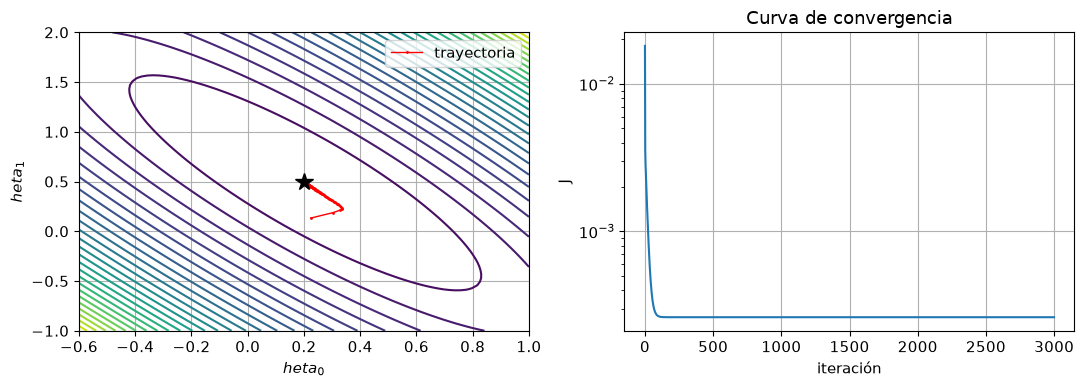

In [11]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.contour(t0g, t1g, Jg, 30, cmap="viridis")
plt.plot(hist[:, 0], hist[:, 1], "r.-", ms=2, lw=1, label="trayectoria")
plt.plot(*theta_real, "k*", ms=13)
plt.xlabel(r"$	heta_0$"); plt.ylabel(r"$	heta_1$"); plt.legend()

plt.subplot(122)
plt.semilogy(hist[:, 2])
plt.xlabel("iteración"); plt.ylabel("J"); plt.title("Curva de convergencia")
plt.tight_layout(); plt.show()

**Pregunta guía.** Vuelva a correr `descenso` con `alpha=3.0` y con `alpha=0.01`. ¿Qué observa en la curva de convergencia en cada caso?

c:\CCA\005_CCA_Estudiantes\Laboratorios\01_LabPatronesAgente\Tools\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\valen\AppData\Local\Temp\ipykernel_15932\2986306723.py:8: RuntimeWarning: overflow encountered in square
  return ((H(X, t0, t1) - y) ** 2).mean() / 2
c:\CCA\005_CCA_Estudiantes\Laboratorios\01_LabPatronesAgente\Tools\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\valen\AppData\Local\Temp\ipykernel_15932\2422375448.py:13: RuntimeWarning: invalid value encountered in scalar multiply
  ld1.append(err[i] * X[i])
C:\Users\valen\AppData\Local\Temp\ipykernel_15932\2422375448.py:22: RuntimeWarning: invalid value encountered in scalar subtract
  t0 = t0 - alpha * d0
c:\CCA\005_CCA_Estudiantes\Laboratorios\01_LabPatronesAgente\Tools\.venv\L

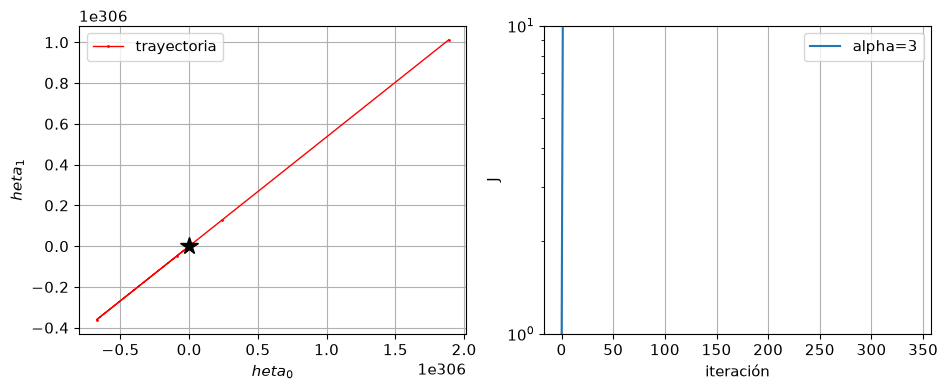

In [12]:
# Alpha = 3
t0_gd_3, t1_gd_3, hist_3 = descenso(X, y, alpha=3, n_iter=3000, t0=0.0, t1=0.0)

plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.contour(t0g, t1g, Jg, 30, cmap="viridis")
plt.plot(hist_3[:, 0], hist_3[:, 1], "r.-", ms=2, lw=1, label="trayectoria")
plt.plot(*theta_real, "k*", ms=13)
plt.xlabel(r"$	heta_0$"); plt.ylabel(r"$	heta_1$"); plt.legend()

plt.subplot(122)

plt.semilogy(hist_3[:, 2], label="alpha=3")
plt.xlabel("iteración"); plt.ylabel("J"); plt.legend(); plt.show()





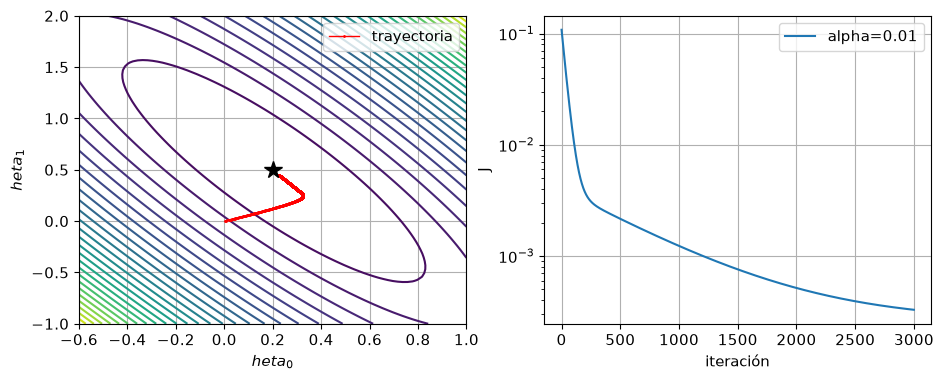

In [13]:
# Alpha = 0.01
t0_gd_001, t1_gd_001, hist_001 = descenso(X, y, alpha=0.01, n_iter=3000, t0=0.0, t1=0.0)
plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.contour(t0g, t1g, Jg, 30, cmap="viridis")
plt.plot(hist_001[:, 0], hist_001[:, 1], "r.-", ms=2, lw=1, label="trayectoria")
plt.plot(*theta_real, "k*", ms=13)
plt.xlabel(r"$	heta_0$"); plt.ylabel(r"$	heta_1$"); plt.legend()

plt.subplot(122)
plt.semilogy(hist_001[:, 2], label="alpha=0.01")
plt.xlabel("iteración"); plt.ylabel("J"); plt.legend(); plt.show()

---
# Parte 3 — Regresión multivariada (versión vectorizada)

Con $n$ características, escribimos todo en forma matricial. Añadimos una columna de unos para el intercepto:

$$X=\begin{bmatrix}1 & x_1^{(1)} & \cdots & x_n^{(1)}\\ \vdots & & & \vdots\\ 1 & x_1^{(m)} & \cdots & x_n^{(m)}\end{bmatrix}_{m\times(n+1)},\qquad \Theta=\begin{bmatrix}\theta_0\\ \vdots\\ \theta_n\end{bmatrix}$$

$$h = X\Theta,\qquad J(\Theta)=\frac{1}{2m}\,(h-y)^T(h-y),\qquad \nabla_\Theta J = \frac{1}{m}X^T(h-y)$$

Los bucles de la Parte 2 desaparecen: todo son tres productos matriciales.

In [14]:
def agregar_sesgo(Xf):
    """(m, n) -> (m, n+1) agregando una columna de unos al frente."""
    Xf = np.asarray(Xf, dtype=float)
    if Xf.ndim == 1:
        Xf = Xf.reshape(-1, 1)                        # Si tiene una sola caracteristica, la convertimos en una matriz columna
    return np.hstack([np.ones((Xf.shape[0], 1)), Xf]) # Se le agrega (pega) una columna de unos al frente


def h_lin(Theta, Xb):
    return Xb @ Theta


def J_lin(Theta, Xb, y):
    r = h_lin(Theta, Xb) - y
    return (r @ r) / (2 * len(y)) # r@r es el producto punto de r consigo mismo.

### ✏️ Ejercicio 3.1 — El gradiente vectorizado

Traduzca $\nabla_\Theta J = \frac{1}{m}X^T(h-y)$ a una sola línea de numpy.

In [ ]:
def grad_lin(Theta, Xb, y):
    m = len(y)
    return  1/m * Xb.T@(h_lin(Theta, Xb) - y) # TODO: una línea


def descenso_vec(Xb, y, alpha=0.1, n_iter=5000, Theta=None):
    Theta = np.zeros(Xb.shape[1]) if Theta is None else np.array(Theta, dtype=float)
    hist = [] #Termina siendo unaaray 1D con los valores de J en cada iteración
    for _ in range(n_iter):
        Theta = Theta - alpha * grad_lin(Theta, Xb, y)
        hist.append(J_lin(Theta, Xb, y))
    return Theta, np.array(hist) # devuelve el ultimo vector de theta calculado y los valores de J en cada iteración


In [ ]:
# ✅ Checkpoint 3.1 — verificación numérica del gradiente
# Comparamos su fórmula contra una derivada numérica: es la mejor forma
# de detectar errores de signo o de transposición.
def grad_numerico(fun, Theta, eps=1e-6):
    g = np.zeros_like(Theta)
    for k in range(len(Theta)):
        e = np.zeros_like(Theta); e[k] = eps # vector de ceros, excepto en la posición k, donde es eps. Esto se hace para 
        g[k] = (fun(Theta + e) - fun(Theta - e)) / (2 * eps)
    return g


Xb_test = agregar_sesgo(rng.normal(size=(30, 3))) # Xb es una matriz de 30 filas y 4 columnas (3 características + sesgo (columna de 1))
y_test = rng.normal(size=30) # vector de 30 observaciones que se van a predecir
Th_test = rng.normal(size=4) # vector de theta de 4 elementos (3 características + sesgo) con componentes aleatorias cualquiera, no el óptimo, no ceros

g_ana = grad_lin(Th_test, Xb_test, y_test) # gradiente analítico calculado con la fórmula que implementamos
g_num = grad_numerico(lambda T: J_lin(T, Xb_test, y_test), Th_test) # gradiente numérico calculado con la derivada numérica
assert np.allclose(g_ana, g_num, atol=1e-6), "el gradiente analítico no coincide con el numérico"
print("Correcto ✔  gradiente analítico == gradiente numérico")

print(Xb_test.shape)

Correcto ✔  gradiente analítico == gradiente numérico
(30, 4)


Theta estimado: [-0.9969  0.2181  0.4957]    (real: [-1, 0.2, 0.5])


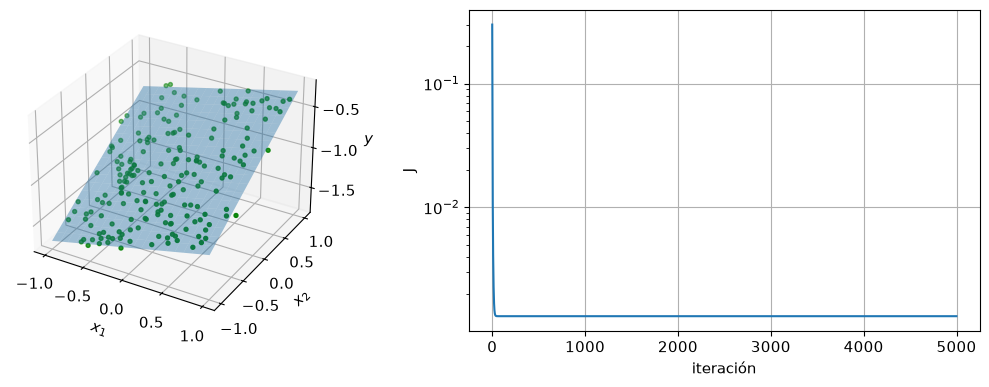

In [ ]:
# Datos: un plano  y = -1 + 0.2*x1 + 0.5*x2  con ruido
N = 200 # Total de datos
x1 = rng.uniform(-1, 1, N) # caracteristica 1
x2 = rng.uniform(-1, 1, N) # caracteristica 2
y2 = -1.0 + 0.2 * x1 + 0.5 * x2 + rng.normal(0, 0.05, N) # observaciones con ruido

Xb = agregar_sesgo(np.column_stack([x1, x2]))
Theta_gd, hist2 = descenso_vec(Xb, y2, alpha=0.3, n_iter=5000)
print("Theta estimado:", np.round(Theta_gd, 4), "   (real: [-1, 0.2, 0.5])")

fig = plt.figure(figsize=(11, 4))
ax = fig.add_subplot(121, projection="3d")
g1, g2 = np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20)) # valores elegidos aleatoriamente para cada característica, para graficar la superficie del plano estimado por el modelo. Es decir, que esos valores, hace las veces de las meidicones que pudimos haber obtenido, por ejemplo
ax.plot_surface(g1, g2, Theta_gd[0] + Theta_gd[1] * g1 + Theta_gd[2] * g2, alpha=0.4) # Graficar los valores de las carateristicas (g1, g2) y el valor H estimado por el modelo (Theta_gd[0] + Theta_gd[1] * g1 + Theta_gd[2] * g2)
ax.scatter(x1, x2, y2, c="g", s=8)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$y$")

ax2 = fig.add_subplot(122)
ax2.semilogy(hist2); ax2.set_xlabel("iteración"); ax2.set_ylabel("J")
plt.tight_layout(); plt.show()



---
# Parte 4 — Escalamiento de características

¿Qué pasa si una característica vive en $[-1,1]$ y otra en $[-2000,2000]$? La superficie de coste se vuelve un valle largo y estrecho: el mismo $\alpha$ es demasiado grande en una dirección y demasiado pequeño en la otra.

La solución es **estandarizar**:

$$x_j \leftarrow \frac{x_j-\mu_j}{s_j}$$

con $\mu_j$ la media y $s_j$ la desviación estándar (o el rango) de la característica $j$.

In [ ]:
# Sin escalar: x2 tiene un rango 2000 veces mayor que x1
n = 100
z1 = rng.uniform(-1, 1, n)
z2 = rng.uniform(-2000, 2000, n)
yz = 2 * z1 - 3 * z2 + rng.normal(0, 0.1, n)

Xb_mal = agregar_sesgo(np.column_stack([z1, z2]))
with np.errstate(over="ignore", invalid="ignore"):
    _, hist_mal = descenso_vec(Xb_mal, yz, alpha=0.3, n_iter=30) # Se calcula el descenso de gradiente con un alpha grande, que hace que diverja. Se ignoran los errores de overflow y invalid, porque se espera que diverja y genere valores muy grandes.

print("Coste en las 5 primeras iteraciones:", hist_mal[:5]) 
print("Coste tras 30 iteraciones          :", hist_mal[-1], " ← diverge")
print()
print("Con alpha mucho más pequeño tampoco es buena idea:")
with np.errstate(over="ignore", invalid="ignore"):
    Th_mal, h2 = descenso_vec(Xb_mal, yz, alpha=1e-8, n_iter=2000)
print("  alpha=1e-8, 2000 iteraciones -> Theta =", np.round(Th_mal, 3), " (real: [0, 2, -3])")
print("  el coeficiente de x2 ya está, pero el de x1 ni se ha movido")

Coste en las 5 primeras iteraciones: [6.87089831e+17 8.79634854e+28 1.12613728e+40 1.44171775e+51
 1.84573417e+62]
Coste tras 30 iteraciones          : inf  ← diverge

Con alpha mucho más pequeño tampoco es buena idea:
  alpha=1e-8, 2000 iteraciones -> Theta = [ 0. -0. -3.]  (real: [0, 2, -3])
  el coeficiente de x2 ya está, pero el de x1 ni se ha movido


### ✏️ Ejercicio 4.1 — Estandarice y vuelva a entrenar

In [36]:
def estandarizar(Xf):
    """Devuelve (X escalado, mu, sigma) columna por columna."""
    Xf = np.asarray(Xf, dtype=float)
    
    mu = [] # TODO: media por columna
    sigma = [] # TODO: desviación estándar por columna
    
    for i in range(Xf.shape[1]): # me paro en la columna i
        val_col = []
        for j in range(Xf.shape[0]): # recorro todas las filas de la columna i
            val_col.append(Xf[j][i])
            
        mu_col = np.mean(val_col)
        sigma_col=np.std(val_col)
        mu.append(mu_col)
        sigma.append(sigma_col)
                
    return (Xf - mu) / sigma, mu, sigma

# Verificar el modelo con la estandarización o escalado de la matriz de caracteriticas Z

Z = np.column_stack([z1, z2])
Z_esc, mu, sigma = estandarizar(Z) #Devuelve el Z escalado, la media y la desviación estándar de cada columna. Se hace para que las características tengan un rango similar y el descenso de gradiente funcione mejor.
Xb_bien = agregar_sesgo(Z_esc)
Theta_esc, hist_bien = descenso_vec(Xb_bien, yz, alpha=0.3, n_iter=2000)
print("Coste final tras escalar:", round(hist_bien[-1], 4))
print("Media de cada columna:", mu)
print("Desviación estándar de cada columna:", sigma)


Coste final tras escalar: 0.0035
Media de cada columna: [np.float64(-0.08324588202258962), np.float64(-56.82873428602179)]
Desviación estándar de cada columna: [np.float64(0.5785355447241328), np.float64(1090.6199155634963)]


In [40]:
# ✅ Checkpoint 4.1
assert np.allclose(Z_esc.mean(axis=0), 0, atol=1e-10), "la media escalada debe ser 0" # dice que la media de cada columna escalada debe ser 0, con una tolerancia de 1e-10
#print("Media de cada columna después del escalado:", Z_esc.mean(axis=0))
assert np.allclose(Z_esc.std(axis=0), 1, atol=1e-10), "la desviación escalada debe ser 1"
assert np.isfinite(hist_bien[-1]) and hist_bien[-1] < 10, "el descenso aún no converge"
print("Correcto ✔")

# Los parámetros escalados se devuelven al espacio original así:
t_orig = Theta_esc[1:] / sigma
t0_orig = Theta_esc[0] - (Theta_esc[1:] * mu / sigma).sum()
print("Coeficientes en unidades originales:", np.round([t0_orig, *t_orig], 3), " (real: [0, 2, -3])")
print("Coeficientes escalados:", Theta_esc)

Correcto ✔
Coeficientes en unidades originales: [ 0.013  2.041 -3.   ]  (real: [0, 2, -3])
Coeficientes escalados: [ 1.70328773e+02  1.18107363e+00 -3.27185374e+03]


---
# Parte 5 — La ecuación normal

Para el error cuadrático **no hace falta iterar**: el mínimo tiene solución cerrada. Partiendo de

$$J(\Theta)=\frac{1}{2m}(X\Theta-y)^T(X\Theta-y),\qquad \nabla_\Theta J=\frac{1}{m}\left(X^TX\,\Theta-X^Ty\right)$$

e imponiendo $\nabla_\Theta J = 0$:

$$\boxed{\;\Theta=(X^TX)^{-1}X^Ty\;}$$

*(La demostración completa queda como tarea; use $\nabla_x b^Tx=b$ y $\nabla_x x^TAx=2Ax$ con $A$ simétrica.)*

**Nota práctica:** nunca invierta la matriz explícitamente. `np.linalg.solve(A, b)` resuelve $A\Theta=b$ y es más estable y rápido que `np.linalg.inv(A) @ b`.

### ✏️ Ejercicio 5.1 — Implemente la ecuación normal

In [41]:
def ecuacion_normal(Xb, y):
    """Theta = (X^T X)^{-1} X^T y, resuelto con np.linalg.solve."""
    A = Xb.T@Xb   # TODO
    b = Xb.T@y   # TODO
    return np.linalg.solve(A, b)


Theta_ne = ecuacion_normal(Xb, y2)
print("Ecuación normal   :", np.round(Theta_ne, 4))
print("Gradiente desc.   :", np.round(Theta_gd, 4))

Ecuación normal   : [-0.9969  0.2181  0.4957]
Gradiente desc.   : [-0.9969  0.2181  0.4957]


In [42]:
# ✅ Checkpoint 5.1
assert np.allclose(Theta_ne, Theta_gd, atol=1e-3), "los dos métodos deberían coincidir"
assert J_lin(Theta_ne, Xb, y2) <= J_lin(Theta_gd, Xb, y2) + 1e-9, "la solución cerrada es la óptima"
print("Correcto ✔  ambos métodos llegan al mismo mínimo")

Correcto ✔  ambos métodos llegan al mismo mínimo


In [44]:
!pip install scikit-learn

                                              0.0/8.3 MB ? eta -:--:--
                                              0.0/8.3 MB 1.4 MB/s eta 0:00:07
                                              0.0/8.3 MB 1.4 MB/s eta 0:00:07
                                              0.1/8.3 MB 573.4 kB/s eta 0:00:15
                                              0.1/8.3 MB 585.1 kB/s eta 0:00:14
                                              0.1/8.3 MB 514.3 kB/s eta 0:00:16
     -                                        0.2/8.3 MB 811.5 kB/s eta 0:00:10
     -                                        0.2/8.3 MB 754.9 kB/s eta 0:00:11
     -                                        0.4/8.3 MB 1.1 MB/s eta 0:00:08
     --                                       0.5/8.3 MB 1.3 MB/s eta 0:00:07
     ---                                      0.7/8.3 MB 1.5 MB/s eta 0:00:06
     ----                                     1.0/8.3 MB 2.0 MB/s eta 0:00:04
     -----                                    1.1/8.3 MB 2.1 


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
# Datos reales: diabetes (442 pacientes, 10 características)
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

datos = load_diabetes()
Xd, yd = datos.data, datos.target
Xdb = agregar_sesgo(Xd)

Theta_d = ecuacion_normal(Xdb, yd)
skl = LinearRegression().fit(Xd, yd) # Datos con los cuales se podrá comparar el resultado de la ecuación normal.

print("Nuestro intercepto :", round(Theta_d[0], 4), "  sklearn:", round(skl.intercept_, 4))
print("Máxima diferencia en los coeficientes:", np.abs(Theta_d[1:] - skl.coef_).max())

r2 = 1 - ((Xdb @ Theta_d - yd) ** 2).sum() / ((yd - yd.mean()) ** 2).sum()
print("R^2 =", round(r2, 4))

Nuestro intercepto : 152.1335   sklearn: 152.1335
Máxima diferencia en los coeficientes: 2.1714186004828662e-11
R^2 = 0.5177


### ¿Gradiente descendente o ecuación normal?

| | Gradiente descendente | Ecuación normal |
|---|---|---|
| Hiperparámetros | requiere elegir $\alpha$ y n.º de iteraciones | ninguno |
| Escalamiento | imprescindible | innecesario |
| Costo | $O(k\,n^2)$ | $O(n^3)$ por la inversión |
| $n$ grande ($>10^4$) | funciona bien | se vuelve inviable |
| Otros modelos | sirve para logística, redes, etc. | solo mínimos cuadrados |

### ¿Por qué mínimos cuadrados y no otra métrica?

Si suponemos $y^{(i)}=\Theta^TX^{(i)}+\epsilon_i$ con $\epsilon_i\sim\mathcal{N}(0,\sigma^2)$ i.i.d., la verosimilitud es

$$\mathcal{L}(\Theta)=\prod_{i=1}^{m}\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(y^{(i)}-\Theta^TX^{(i)})^2}{2\sigma^2}}
\;\Longrightarrow\;
\ell(\Theta)=\text{cte}-\frac{1}{2\sigma^2}\sum_{i=1}^{m}\left(y^{(i)}-\Theta^TX^{(i)}\right)^2$$

Maximizar $\ell$ es **exactamente** minimizar el error cuadrático. Los mínimos cuadrados son el estimador de máxima verosimilitud bajo ruido gaussiano; si el ruido no es gaussiano, otra métrica puede ser mejor.

---
# Parte 6 — Clasificación: regresión logística

Ahora $y\in\{0,1\}$. Queremos que la salida sea una **probabilidad**, así que pasamos $\Theta^TX$ por la sigmoide:

$$h_\Theta(X)=\sigma(\Theta^TX)=\frac{1}{1+e^{-\Theta^TX}}=P(y=1\mid X;\Theta),
\qquad \sigma'(z)=\sigma(z)\,(1-\sigma(z))$$

La regla de decisión es simplemente el signo del argumento:

* $\Theta^TX \ge 0 \Rightarrow h \ge 0.5 \Rightarrow$ clase 1
* $\Theta^TX < 0 \Rightarrow h < 0.5 \Rightarrow$ clase 0

La ecuación $\Theta^TX = 0$ define la **frontera de decisión**.

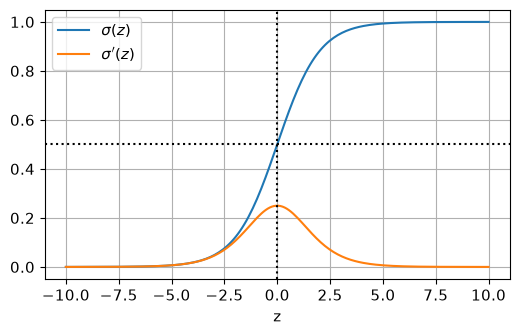

In [46]:
sigmoide = lambda z: 1 / (1 + np.exp(-z))
z = np.linspace(-10, 10, 200)

plt.figure(figsize=(6, 3.5))
plt.plot(z, sigmoide(z), label=r"$\sigma(z)$")
plt.plot(z, sigmoide(z) * (1 - sigmoide(z)), label=r"$\sigma'(z)$")
plt.axhline(0.5, color="k", ls=":"); plt.axvline(0, color="k", ls=":")
plt.xlabel("z"); plt.legend(); plt.show()

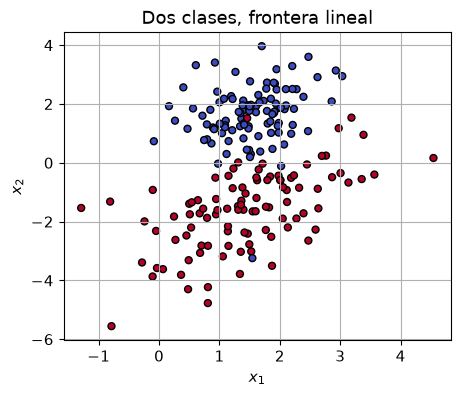

In [64]:
from sklearn.datasets import make_classification, make_circles

# n_samples: número de muestras, n_features: número de características, n_redundant: número de características redundantes, n_informative: número de características reales de las clases, n_clusters_per_class: número de nubes por clase, class_sep: separación entre clases, random_state: semilla para la generación aleatoria de datos

Xc, yc = make_classification(n_samples=200, n_features=2, n_redundant=0,
                             n_informative=2, n_clusters_per_class=1,
                             class_sep=1.5, random_state=1)


plt.figure(figsize=(5, 4))
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k", s=25)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("Dos clases, frontera lineal")
plt.show()

### Fronteras no lineales

Nada obliga a que $\Theta^TX$ sea lineal en las características originales. Si agregamos términos polinómicos, por ejemplo

$$\theta_0+\theta_1x_1+\theta_2x_2+\theta_3x_1^2+\theta_4x_2^2 \ge 0,$$

la frontera puede ser una circunferencia, una elipse, etc.

### ✏️ Ejercicio 6.1 — Encuentre la frontera circular

Para los datos de `make_circles`, con $\Theta=[-r^2,\,0,\,0,\,1,\,1]$ la frontera es $x_1^2+x_2^2=r^2$. Busque el radio $r$ que mejor separa las clases.

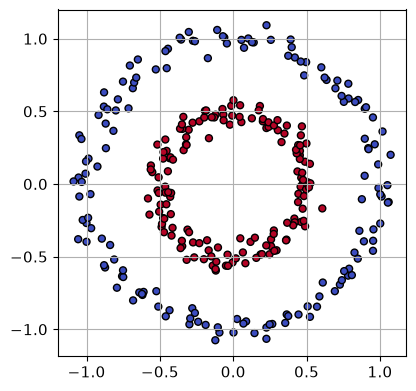

Radio óptimo = 0.636   exactitud = 1.000


In [76]:
Xr, yr = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=0)
# En make_circles la clase 1 es el círculo interior.
# Xr: coordenasa x1 y x2 de los 300 puntos
# yr: la etiqueta de cada punto, es decir, a que anillo pertenece, 0 o 1. La clase 1 es el círculo interior, la clase 0 es el círculo exterior.

# Solo para ver la distribución de los datos
plt.figure(figsize=(4.5, 4.5))
plt.scatter(Xr[:, 0], Xr[:, 1], c=yr, cmap="coolwarm", edgecolor="k", s=25)
plt.show()
#print(Xr)
#print(Xr[1])
#print(yr)


def clasifica_circulo(Xf, r):
    """Devuelve 1 si el punto está dentro del círculo de radio r."""
    inside_points = [] # Por si acaso
    outside_points = [] # Por si acaso
    all_points = []
    for i in range(len(Xf)):
        if (Xf[i][0])**2 + (Xf[i][1])**2 < r**2:
            inside_points.append((Xf[i][0], Xf[i][1]))
            all_points.append(1)
        else:
            outside_points.append((Xf[i][0], Xf[i][1]))
            all_points.append(0)
            
    return all_points                             # TODO: use Xf[:, 0]**2 + Xf[:, 1]**2 y compare con r**2


radios = np.linspace(0.2, 1.0, 100)
exactitudes = np.array([(clasifica_circulo(Xr, r) == yr).mean() for r in radios])
#print(exactitudes)
r_opt = radios[np.argmax(exactitudes)]
print(f"Radio óptimo = {r_opt:.3f}   exactitud = {exactitudes.max():.3f}")

Correcto ✔


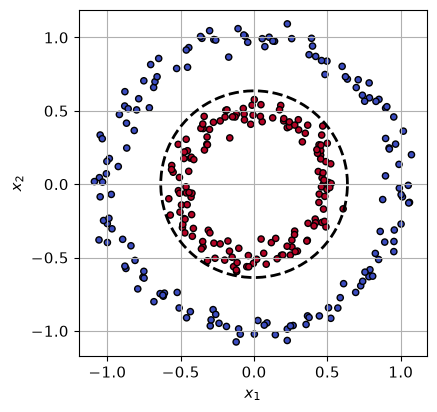

In [74]:
# ✅ Checkpoint 6.1
assert exactitudes.max() > 0.95, "debería poder separar los anillos casi perfectamente"
print("Correcto ✔")

ang = np.linspace(0, 2 * np.pi, 200)
plt.figure(figsize=(4.5, 4.5))
plt.scatter(Xr[:, 0], Xr[:, 1], c=yr, cmap="coolwarm", edgecolor="k", s=20)
plt.plot(r_opt * np.cos(ang), r_opt * np.sin(ang), "k--", lw=2)
plt.axis("equal"); plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.show()

### Función de coste: entropía cruzada

El error cuadrático no sirve aquí (produce una superficie con múltiples mínimos locales). Se usa

$$J(\Theta)=-\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log h_\Theta(X^{(i)})+(1-y^{(i)})\log\left(1-h_\Theta(X^{(i)})\right)\right]$$

que penaliza fuertemente predecir con confianza la clase equivocada. Y aquí está el resultado elegante del laboratorio: su gradiente es

$$\nabla_\Theta J=\frac{1}{m}X^T\left(h_\Theta(X)-y\right)$$

**idéntico en forma al de la regresión lineal**; lo único que cambia es la definición de $h$. (Sale de $\sigma'=\sigma(1-\sigma)$ y de la regla de la cadena.)

### ✏️ Ejercicio 6.2 — Entrene un clasificador desde cero

In [ ]:
def h_log(Theta, Xb):
    return sigmoide(Xb @ Theta)


def J_log(Theta, Xb, y, eps=1e-12): # eps se usa para evitar log(0) que es indefinido
    p = h_log(Theta, Xb)
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))


def grad_log(Theta, Xb, y):
    m = len(y)
    grad = 1/m * Xb.T@(h_log(Theta, Xb) - y)
    return grad    # TODO: la diferencia con grad_lin, es que h_log devuelve valores entre 0 y 1 (sigmoide), mientras que h_lin devuelve valores reales.


def descenso_log(Xb, y, alpha=0.5, n_iter=5000): #Parte 5.7 del taller teórico. Se implementa el descenso de gradiente para regresión logística. Devuelve el vector de parámetros Theta y un historial de los valores de la función de coste J_log en cada iteración.
    Theta, hist = np.zeros(Xb.shape[1]), []
    for _ in range(n_iter):
        Theta = Theta - alpha * grad_log(Theta, Xb, y)
        hist.append(J_log(Theta, Xb, y))
    return Theta, np.array(hist)

#def descenso_vec(Xb, y, alpha=0.1, n_iter=5000, Theta=None):
#    Theta = np.zeros(Xb.shape[1]) if Theta is None else np.array(Theta, dtype=float)
#    hist = [] #Termina siendo una array 1D con los valores de J en cada iteración
#    for _ in range(n_iter):
#        Theta = Theta - alpha * grad_lin(Theta, Xb, y)
#        hist.append(J_lin(Theta, Xb, y))
#    return Theta, np.array(hist) 
#
#
#def descenso(X, y, alpha=0.5, n_iter=3000, t0=0.0, t1=0.0):
#    hist = []
#    for _ in range(n_iter):
#        d0, d1 = grad_J(t0, t1, X, y)
#        t0 = t0 - alpha * d0
#        t1 = t1 - alpha * d1
#        hist.append((t0, t1, J(t0, t1, X, y)))
#    return t0, t1, np.array(hist) # devuelve el ultimo valor de theta_0, theta_1 calculado


Xcb = agregar_sesgo(Xc)
Theta_log, hist_log = descenso_log(Xcb, yc)
pred = (h_log(Theta_log, Xcb) >= 0.5).astype(int) # Regla de desición: si la probabilidad es mayor o igual a 0.5, se predice la clase 1, de lo contrario, la clase 0.
acc_propio = (pred == yc).mean()
print("Theta:", np.round(Theta_log, 3), "  exactitud:", round(acc_propio, 3))

Theta: [-1.762  1.46  -2.797]   exactitud: 0.975


In [ ]:
# ✅ Checkpoint 6.2 — contra sklearn y contra el gradiente numérico
from sklearn.linear_model import LogisticRegression

g_ana = grad_log(np.array([0.3, -0.2, 0.5]), Xcb, yc)
g_num = grad_numerico(lambda T: J_log(T, Xcb, yc), np.array([0.3, -0.2, 0.5]))
assert np.allclose(g_ana, g_num, atol=1e-6), "revise grad_log"

ref = LogisticRegression(C=1e6, max_iter=5000).fit(Xc, yc)
assert abs(acc_propio - ref.score(Xc, yc)) < 0.05, "exactitud lejos de la de sklearn"
print(f"Correcto ✔  sklearn: {ref.score(Xc, yc):.3f}   nuestro: {acc_propio:.3f}")

Correcto ✔  sklearn: 0.975   nuestro: 0.975


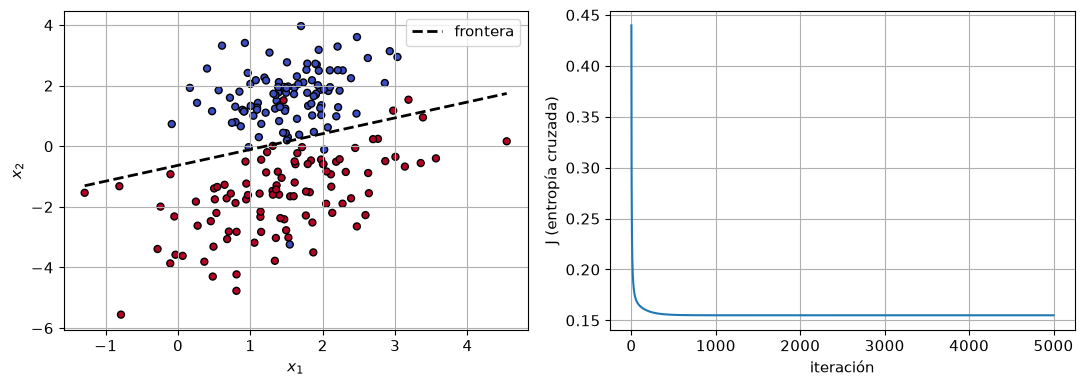

In [79]:
# Frontera de decisión:  theta_0 + theta_1 x1 + theta_2 x2 = 0
xx = np.linspace(Xc[:, 0].min(), Xc[:, 0].max(), 50)
yy = -(Theta_log[0] + Theta_log[1] * xx) / Theta_log[2]

plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k", s=25)
plt.plot(xx, yy, "k--", lw=2, label="frontera")
plt.ylim(Xc[:, 1].min() - 0.5, Xc[:, 1].max() + 0.5)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend()

plt.subplot(122)
plt.plot(hist_log); plt.xlabel("iteración"); plt.ylabel("J (entropía cruzada)")
plt.tight_layout(); plt.show()

---
# Parte 7 — Multiclase y regularización

**Multiclase.** Con $K>2$ clases hay dos estrategias:

* *Uno contra todos*: se entrenan $K$ clasificadores binarios (clase $k$ vs. el resto) y se elige el de mayor probabilidad.
* *Softmax*: se generaliza la sigmoide a $P(y=k\mid X)=\dfrac{e^{\Theta_k^TX}}{\sum_j e^{\Theta_j^TX}}$ y se entrena un solo modelo.

**Regularización.** Para controlar el sobreajuste se penalizan los parámetros grandes:

$$J_{reg}(\Theta)=J(\Theta)+\frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2
\qquad\Longrightarrow\qquad
\theta_j := \theta_j\left(1-\alpha\frac{\lambda}{m}\right)-\frac{\alpha}{m}\sum_{i=1}^{m}\left(h_\Theta(X^{(i)})-y^{(i)}\right)x_j^{(i)}$$

El intercepto $\theta_0$ **no** se regulariza. En `scikit-learn` el parámetro es `C` $=1/\lambda$: **C pequeño = mucha regularización**.

In [88]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

iris = load_iris()
Xi, yi = iris.data, iris.target # 150 flores, cada una con 4 características. yi 
                                # yi tiene 150 valores, pero ahora 3 clases posibles: 0,1,2 (multiclases)
Xtr, Xte, ytr, yte = train_test_split(Xi, yi, test_size=0.3, stratify=yi, random_state=42)

modelo = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000)) 
modelo.fit(Xtr, ytr) # entrenamiento del modelo con los datos de entrenamiento (Xtr, ytr)
print("Exactitud entrenamiento:", round(modelo.score(Xtr, ytr), 3)) # 
print("Exactitud prueba       :", round(modelo.score(Xte, yte), 3))

flor = np.array([[5.9, 3.0, 5.1, 1.8]]) # características de una flor de prueba m=1 (un solo dato). Análogo a X
p = modelo.predict_proba(flor)[0]
print(zip(iris.target_names, p))
for nombre, prob in zip(iris.target_names, p):
    print(f"  P({nombre:<12}) = {prob:.3f}")
    

Exactitud entrenamiento: 0.981
Exactitud prueba       : 0.911
  P(setosa      ) = 0.005
  P(versicolor  ) = 0.341
  P(virginica   ) = 0.653


### ✏️ Ejercicio 7.1 — El efecto de la regularización

Barra `C` en escala logarítmica y grafique la exactitud en entrenamiento y en prueba.

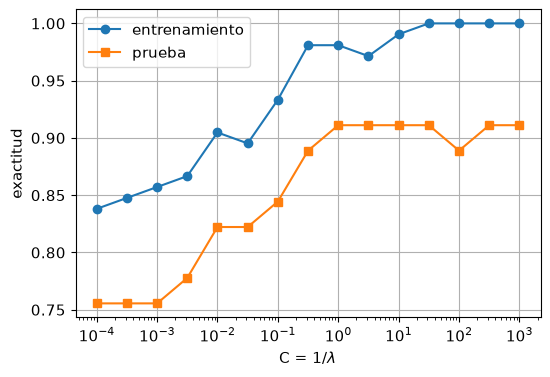

In [89]:
Cs = np.logspace(-4, 3, 15) # genera 15 valores espaciados logaritmicamente
acc_tr, acc_te = [], []

for c in Cs:
    m_ = make_pipeline(StandardScaler(), LogisticRegression(C=c, max_iter=1000))
    m_.fit(Xtr, ytr)
    acc_tr.append(m_.score(Xtr, ytr))   # TODO: exactitud en entrenamiento
    acc_te.append(m_.score(Xte, yte))   # TODO: exactitud en prueba

plt.figure(figsize=(6, 4))
plt.semilogx(Cs, acc_tr, "o-", label="entrenamiento")
plt.semilogx(Cs, acc_te, "s-", label="prueba")
plt.xlabel("C = 1/$\\lambda$"); plt.ylabel("exactitud"); plt.legend(); plt.show()

In [90]:
# ✅ Checkpoint 7.1
assert len(acc_tr) == len(Cs) and len(acc_te) == len(Cs), "faltan valores en el barrido"
assert acc_tr[0] < acc_tr[-1], "con C muy pequeño el modelo debe quedar subajustado"
print(f"Correcto ✔  mejor C = {Cs[int(np.argmax(acc_te))]:.4g}  "
      f"(exactitud de prueba {max(acc_te):.3f})")

Correcto ✔  mejor C = 1  (exactitud de prueba 0.911)



## Preguntas de análisis (para el informe)

1. ¿Por qué el error cuadrático produce una superficie de coste convexa mientras que aplicado a la sigmoide no lo hace?
2. Usted entrena con $\alpha=0.01$ durante 100 iteraciones y el coste baja muy poco. Enumere dos causas posibles y cómo distinguirlas.
3. Con $n=50\,000$ características, ¿usaría la ecuación normal? Justifique con la tabla de la Parte 5.
4. En la gráfica del Ejercicio 7.1, ¿qué región corresponde a subajuste y cuál a sobreajuste? ¿Qué valor de $C$ reportaría y por qué?

## Retos opcionales

* **A. Otras métricas.** Generalice el coste a $J=\frac{1}{pm}\sum_i (h_\theta(x^{(i)})-y^{(i)})^p$. Compare los $\Theta$ obtenidos con $p=1,2,3$ sobre los datos de la Parte 1 y explique cuál es más robusto a valores atípicos (agregue algunos y compruébelo).
* **B. Curvas de aprendizaje.** Grafique $J_{train}$ y $J_{test}$ en función del tamaño del conjunto de entrenamiento para el modelo de la Parte 5. ¿Qué diagnóstico sugieren?
* **C. Clasificación de púlsares.** Con el dataset [HTRU2](https://archive.ics.uci.edu/ml/datasets/HTRU2), construya un clasificador logístico: divida en train/test, entrene, analice las curvas de aprendizaje y aplique regularización. Discuta por qué la exactitud es una métrica engañosa en un dataset tan desbalanceado.

## Referencias

1. Stanford CS229 — <http://cs229.stanford.edu/syllabus.html>
2. A. Ng, *Machine Learning* (Coursera), semanas 1–3.
3. A. Géron, *Hands-On Machine Learning*, cap. 4.
4. Documentación de scikit-learn — <https://scikit-learn.org/stable/>